### Tutorial for 'Pi Mensae' Exoplanet Transit
##### Followed by Cohen Panneri

**Imports:**

In [1]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

/Users/cohen/anaconda3/envs/astro311/lib/python3.11/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


### 1. Accessing Data Products
#####    - full frame image: search_tesscut()
#####    - target pixel file: search_targetpixelfile()
#####    - pre-made lightcurve file: search_lightcurve()

In [2]:
search_ffi = lk.search_tesscut('Pi Mensae')
search_tpf = lk.search_targetpixelfile('Pi Mensae')
search_lcf = lk.search_lightcurve('Pi Mensae')

*Search full frame images:*

In [3]:
search_ffi

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 04,2018,TESScut,1426,Pi Mensae,0.0
1,TESS Sector 01,2018,TESScut,1426,Pi Mensae,0.0
2,TESS Sector 13,2019,TESScut,1426,Pi Mensae,0.0
3,TESS Sector 11,2019,TESScut,1426,Pi Mensae,0.0
4,TESS Sector 12,2019,TESScut,1426,Pi Mensae,0.0
5,TESS Sector 08,2019,TESScut,1426,Pi Mensae,0.0
6,TESS Sector 27,2020,TESScut,475,Pi Mensae,0.0
7,TESS Sector 31,2020,TESScut,475,Pi Mensae,0.0
8,TESS Sector 28,2020,TESScut,475,Pi Mensae,0.0


*Search target pixel files:*

In [4]:
search_tpf

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 01,2018,SPOC,120,261136679,0.0
1,TESS Sector 04,2018,SPOC,120,261136679,0.0
2,TESS Sector 08,2019,SPOC,120,261136679,0.0
3,TESS Sector 11,2019,SPOC,120,261136679,0.0
4,TESS Sector 12,2019,SPOC,120,261136679,0.0
5,TESS Sector 13,2019,SPOC,120,261136679,0.0
6,TESS Sector 27,2020,SPOC,20,261136679,0.0
7,TESS Sector 28,2020,SPOC,20,261136679,0.0
8,TESS Sector 31,2020,SPOC,20,261136679,0.0


*Search light curve files:*

In [5]:
search_lcf

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 01,2018,SPOC,120,261136679,0.0
1,TESS Sector 04,2018,SPOC,120,261136679,0.0
2,TESS Sector 08,2019,SPOC,120,261136679,0.0
3,TESS Sector 11,2019,SPOC,120,261136679,0.0
4,TESS Sector 12,2019,SPOC,120,261136679,0.0
5,TESS Sector 13,2019,SPOC,120,261136679,0.0
6,TESS Sector 27,2020,SPOC,20,261136679,0.0
7,TESS Sector 28,2020,SPOC,20,261136679,0.0
8,TESS Sector 31,2020,SPOC,20,261136679,0.0


***Creating a Lghtcurve:***

Filter author (SPOC) and cadence time (120):

In [7]:
search_lcf_refined = lk.search_lightcurve('Pi Mensae', author="SPOC", exptime=120)
search_lcf_refined

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 01,2018,SPOC,120,261136679,0.0
1,TESS Sector 04,2018,SPOC,120,261136679,0.0
2,TESS Sector 08,2019,SPOC,120,261136679,0.0
3,TESS Sector 11,2019,SPOC,120,261136679,0.0
4,TESS Sector 12,2019,SPOC,120,261136679,0.0
5,TESS Sector 13,2019,SPOC,120,261136679,0.0
6,TESS Sector 27,2020,SPOC,120,261136679,0.0
7,TESS Sector 28,2020,SPOC,120,261136679,0.0
8,TESS Sector 31,2020,SPOC,120,261136679,0.0


Download:

In [42]:
lcf = search_lcf_refined.download_all()
lcf

LightCurveCollection of 24 objects:
    0: <TessLightCurve LABEL="TIC 261136679" SECTOR=1 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 261136679" SECTOR=4 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 261136679" SECTOR=8 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 261136679" SECTOR=11 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    4: <TessLightCurve LABEL="TIC 261136679" SECTOR=12 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    5: <TessLightCurve LABEL="TIC 261136679" SECTOR=13 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    6: <TessLightCurve LABEL="TIC 261136679" SECTOR=27 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    7: <TessLightCurve LABEL="TIC 261136679" SECTOR=28 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    8: <TessLightCurve LABEL="TIC 261136679" SECTOR=31 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    9: <TessLightCurve LABEL="TIC 261136679" SECTOR=34 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    10: <TessLightCurve LABEL="TIC 261136679" S

Select sector by object #, this example selects SECTOR 1 data through object 0:

In [43]:
lcf[0]

time,flux,flux_err,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,d,,pix,pix,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,float32,int32,float64,float64,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
1325.2969604950604,1.4641956e+06,1.3036719e+02,1.2319778e-03,70445,1630.67624,260.67540,1.4354926e+06,1.2776145e+02,3.9114688e+03,1.5351995e+01,1.4641956e+06,1.3036719e+02,0,———,———,———,———,1630.67624,8.4099076e-05,260.67540,1.3968609e-04,9.0913408e-02,-7.2966635e-02
1325.2983493645327,1.4643365e+06,1.3035809e+02,1.2319590e-03,70446,1630.64880,260.63392,1.4357199e+06,1.2775254e+02,3.8596919e+03,1.5269516e+01,1.4643365e+06,1.3035809e+02,0,———,———,———,———,1630.64880,8.4054744e-05,260.63392,1.3961994e-04,6.2022530e-02,-1.0871942e-01
1325.299738234005,1.4643485e+06,1.3035931e+02,1.2319401e-03,70447,1630.64806,260.62840,1.4356588e+06,1.2775373e+02,3.8692920e+03,1.5291610e+01,1.4643485e+06,1.3035931e+02,0,———,———,———,———,1630.64806,8.4062471e-05,260.62840,1.3959571e-04,6.1673984e-02,-1.1394957e-01
1325.301127103477,1.4643674e+06,1.3035008e+02,1.2319213e-03,70448,1630.64752,260.61434,1.4356190e+06,1.2774468e+02,3.8398132e+03,1.5262703e+01,1.4643674e+06,1.3035008e+02,0,———,———,———,———,1630.64752,8.4045743e-05,260.61434,1.3958366e-04,6.0909923e-02,-1.2573890e-01
1325.3025159730657,1.4642560e+06,1.3034836e+02,1.2319025e-03,70449,1630.64057,260.61412,1.4355810e+06,1.2774299e+02,3.8384204e+03,1.5262712e+01,1.4642560e+06,1.3034836e+02,0,———,———,———,———,1630.64057,8.4043444e-05,260.61412,1.3952980e-04,5.3837594e-02,-1.2532526e-01
1325.303904842538,1.4644681e+06,1.3035623e+02,1.2318837e-03,70450,1630.63971,260.61326,1.4358005e+06,1.2775071e+02,3.8069717e+03,1.5240330e+01,1.4644681e+06,1.3035623e+02,0,———,———,———,———,1630.63971,8.4056861e-05,260.61326,1.3949080e-04,5.2977830e-02,-1.2562653e-01
1325.3052937121265,1.4643586e+06,1.3035381e+02,1.2318649e-03,70451,1630.64385,260.60708,1.4356219e+06,1.2774834e+02,3.8431169e+03,1.5283619e+01,1.4643586e+06,1.3035381e+02,0,———,———,———,———,1630.64385,8.4062158e-05,260.60708,1.3951714e-04,5.7222184e-02,-1.3051888e-01
1325.3066825815986,1.4643564e+06,1.3035527e+02,1.2318461e-03,70452,1630.64220,260.61215,1.4356771e+06,1.2774977e+02,3.8419392e+03,1.5270525e+01,1.4643564e+06,1.3035527e+02,0,———,———,———,———,1630.64220,8.4041087e-05,260.61215,1.3955019e-04,5.5443291e-02,-1.2712292e-01


The above table displays 2 types of lightcurves calculated using different methods:

- **Simple Aperture Photometry (SAP):** The SAP light curve is calculated by summing together the brightness of pixels that fall within an aperture set by the TESS mission. This is often referred to as the optimal aperture, but despite its name, it can sometimes be improved upon! Because the SAP light curve is a sum of the brightness in chosen pixels, it is still subject to systematic artifacts of the mission.

- **Pre-search Data Conditioning SAP flux (PDCSAP) flux:** SAP flux from which long-term trends have been removed using so-called Co-trending Basis Vectors (CBVs). PDCSAP flux is usually cleaner data than the SAP flux and will have fewer systematic trends.

In [10]:
pdcsap = lcf[0].pdcsap_flux

sapflux = lcf[0].sap_flux

Example plots of both:

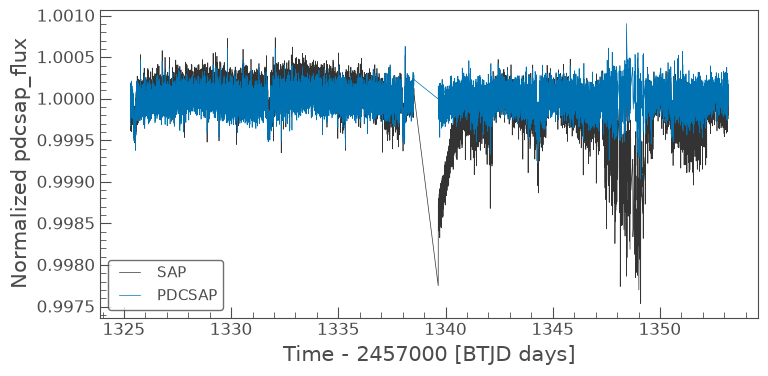

In [11]:
ax = lcf[0].plot(column='sap_flux', normalize=True, label="SAP");
lcf[0].plot(ax=ax, column='pdcsap_flux', normalize=True, label="PDCSAP");

### 2. Analysis and Manipulaiton of Lightcurve '0'
#####    - flatten(): Remove long term trends using a Savitzky–Golay filter
#####    - remove_outliers(): Remove outliers using simple sigma clipping
#####    - remove_nans(): Remove infinite or NaN values (these can occur during thruster firings)
#####    - fold(): Fold the data at a particular period
#####    - bin(): Reduce the time resolution of the array, taking the average value in each bin.

***This example uses PDCSAP Lightcurve 0:***

Text(0.5, 1.0, 'PDCSAP light curve of  Pi Mensae')

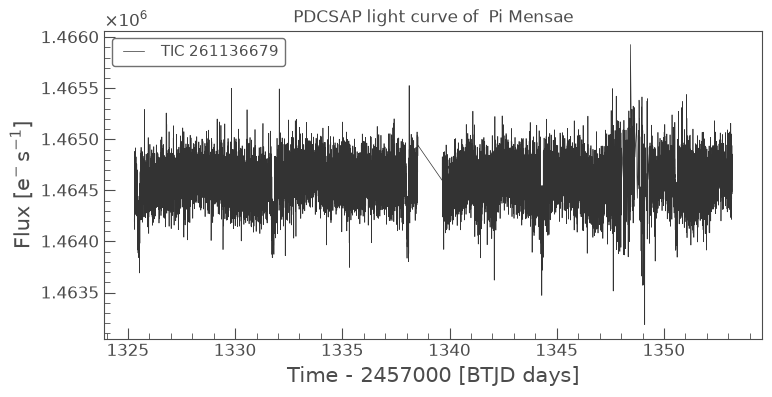

In [13]:
ax = lcf[0].plot()
ax.set_title("PDCSAP light curve of  Pi Mensae")

*Flattening:*

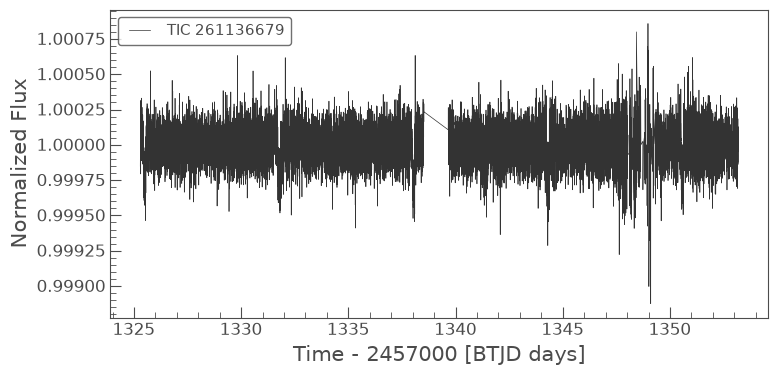

In [14]:
flat_lc = lcf[0].flatten(window_length=1001)
flat_lc.plot();

*Mask the lightcurve, remove any noisy data points, and plot the lightcurve again:*

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

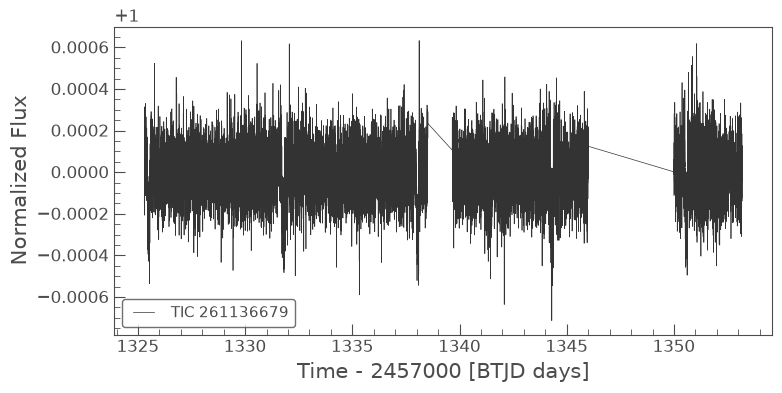

In [16]:
mask = (flat_lc.time.value < 1346) | (flat_lc.time.value > 1350)
masked_lc = flat_lc[mask]
masked_lc.plot()

*The difference:*

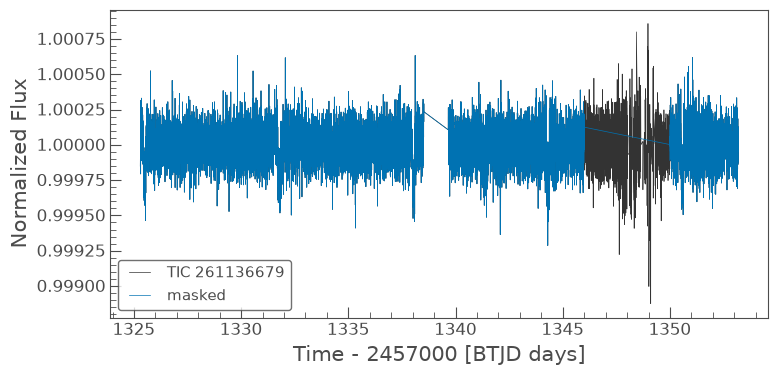

In [17]:
ax = flat_lc.plot()
masked_lc.plot(ax=ax, label='masked');

*Remove Outliers:*

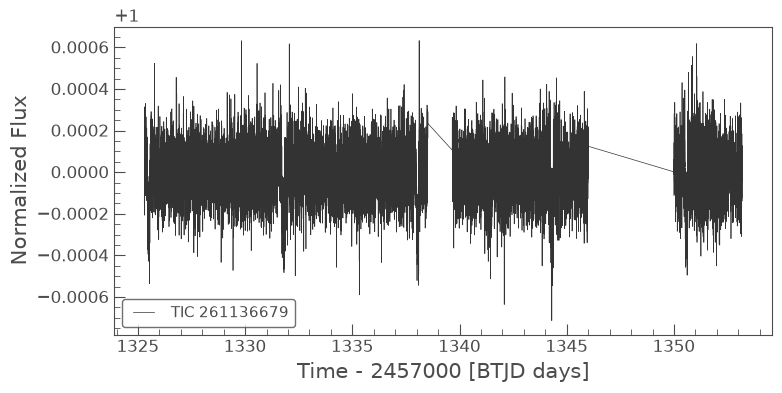

In [18]:
clipped_lc = masked_lc.remove_outliers(sigma=6)
clipped_lc.plot();

*Fold and find the transit:*

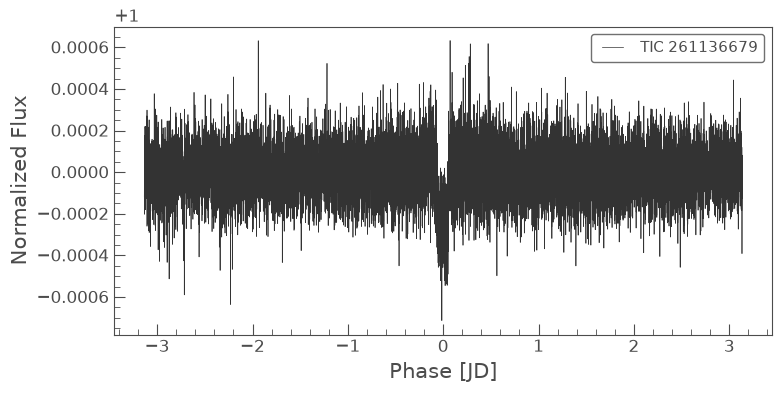

In [19]:
folded_lc = clipped_lc.fold(period=6.27, epoch_time=1325.504)
folded_lc.plot();

*Binning the lightcurve:*

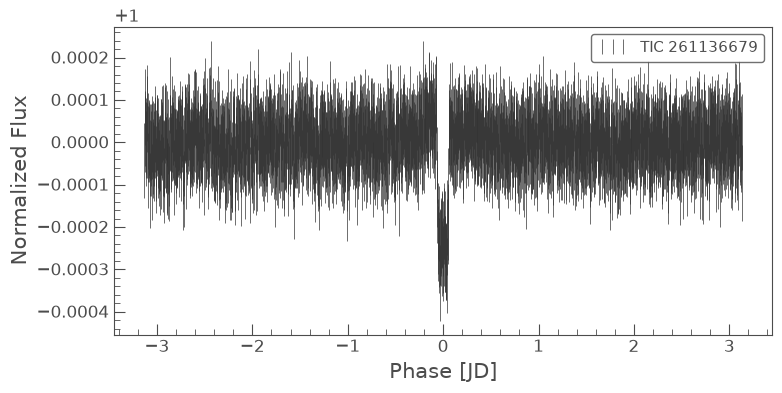

In [20]:
import astropy.units as u
binned_lc = folded_lc.bin(time_bin_size=5*u.minute)
binned_lc.errorbar();

***The transit is at 0 and clearly visible! Hooray!!***

#### 3. Creating a new lightcurve with FFI data:
#####    - Create a 10x10 pixel cutout
#####    - Define an apature mask to filter out irrelevent light

*Pixel cutout:*

In [46]:
#something I ran into is that object number 0 in the search_ffi list is no longer Sector 01, so I used object number 1 instead.
search_ffi

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 04,2018,TESScut,1426,Pi Mensae,0.0
1,TESS Sector 01,2018,TESScut,1426,Pi Mensae,0.0
2,TESS Sector 13,2019,TESScut,1426,Pi Mensae,0.0
3,TESS Sector 11,2019,TESScut,1426,Pi Mensae,0.0
4,TESS Sector 12,2019,TESScut,1426,Pi Mensae,0.0
5,TESS Sector 08,2019,TESScut,1426,Pi Mensae,0.0
6,TESS Sector 27,2020,TESScut,475,Pi Mensae,0.0
7,TESS Sector 31,2020,TESScut,475,Pi Mensae,0.0
8,TESS Sector 28,2020,TESScut,475,Pi Mensae,0.0


<Axes: title={'center': 'Target ID: Pi Mensae, Cadence: 0'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

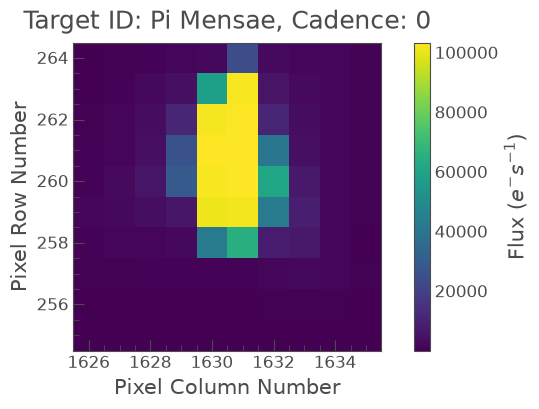

In [44]:
ffi_data = search_ffi[1].download(cutout_size=10)
ffi_data.plot()

In [45]:
target_mask = ffi_data.create_threshold_mask(threshold=10, reference_pixel='center')
n_target_pixels = target_mask.sum()
n_target_pixels

np.int64(18)

<Axes: title={'center': 'Target ID: Pi Mensae, Cadence: 0'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

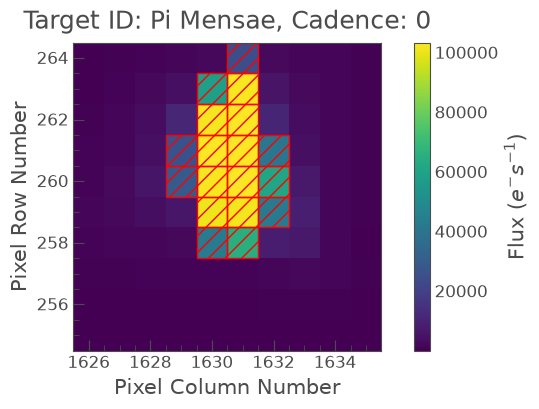

In [47]:
ffi_data.plot(aperture_mask=target_mask, mask_color='r')

*^^^This flux is uncorrected for noise and long-term trends, thus making it SAP*

In [48]:
ffi_lc = ffi_data.to_lightcurve(aperture_mask=target_mask)
ffi_lc

time,flux,flux_err,centroid_col,centroid_row,cadenceno,quality
,electron / s,electron / s,pix,pix,,
Time,float32,float32,float64,float64,int64,int32
1325.324261183436,1316430.75,31.303890228271484,1630.6385441885782,260.61400004745315,0,0
1325.345094309689,1316496.0,31.304616928100586,1630.63890532941,260.614058268241,1,0
1325.3659274373958,1316588.125,31.30562400817871,1630.6395243879658,260.61363650321783,2,0
1325.386760566499,1316589.0,31.305648803710938,1630.6392641770467,260.61324889099075,3,0
1325.407593697,1316634.125,31.306297302246094,1630.6403961686917,260.61333124245886,4,0
1325.4284268288402,1316664.875,31.306610107421875,1630.6403907997208,260.61168543184255,5,0
1325.4492599619616,1316503.25,31.304628372192383,1630.6404545748724,260.6105785492981,6,0
1325.470093096421,1316347.125,31.30280113220215,1630.6417255479462,260.61074264747987,7,0


*Plotting the curve:*

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

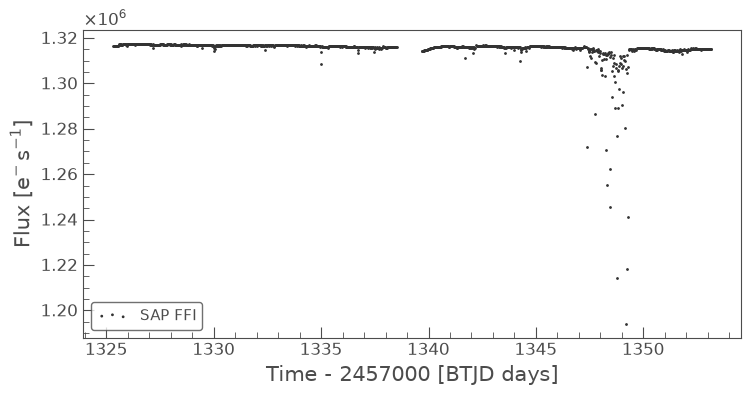

In [49]:
ffi_lc.scatter(label="SAP FFI")

*Apply a mask:*

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

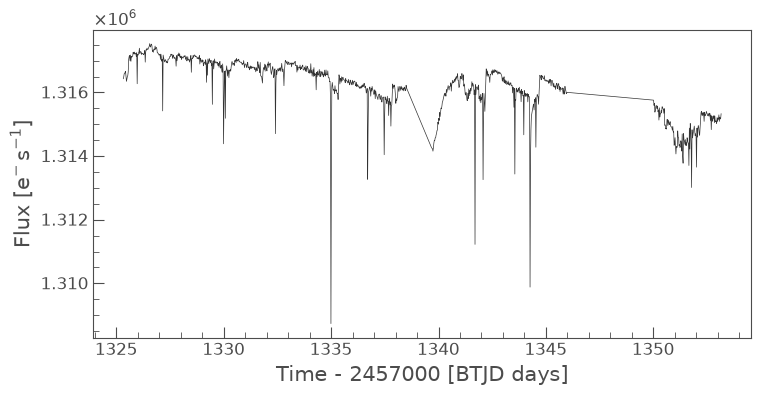

In [50]:
mask_ffi = (ffi_lc.time.value < 1346) | (ffi_lc.time.value > 1350)
masked_lc_ffi = ffi_lc[mask_ffi]
masked_lc_ffi.plot()

*Clip the data:*

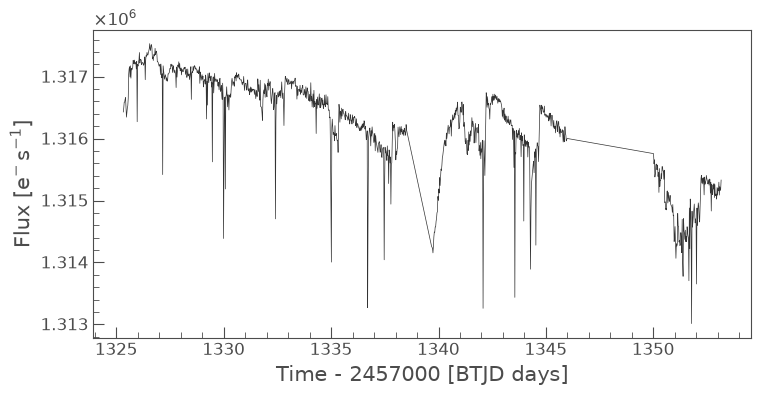

In [51]:
clipped_ffi = masked_lc_ffi.remove_outliers(sigma=6)
clipped_ffi.plot();

*Further clean data with PLD:*
- 'The PLD method has primarily been used to remove systematic trends introduced by small spacecraft motions during observations and has been shown to be successful at improving the precision of data taken by the Spitzer space telescope. PLD works by identifying a set of trends in the pixels surrounding the target star and performing linear regression to create a combination of these trends that effectively models the systematic noise introduced by spacecraft motion. This noise model is then subtracted from the uncorrected light curve. We can apply it to our data using the code shown below.'

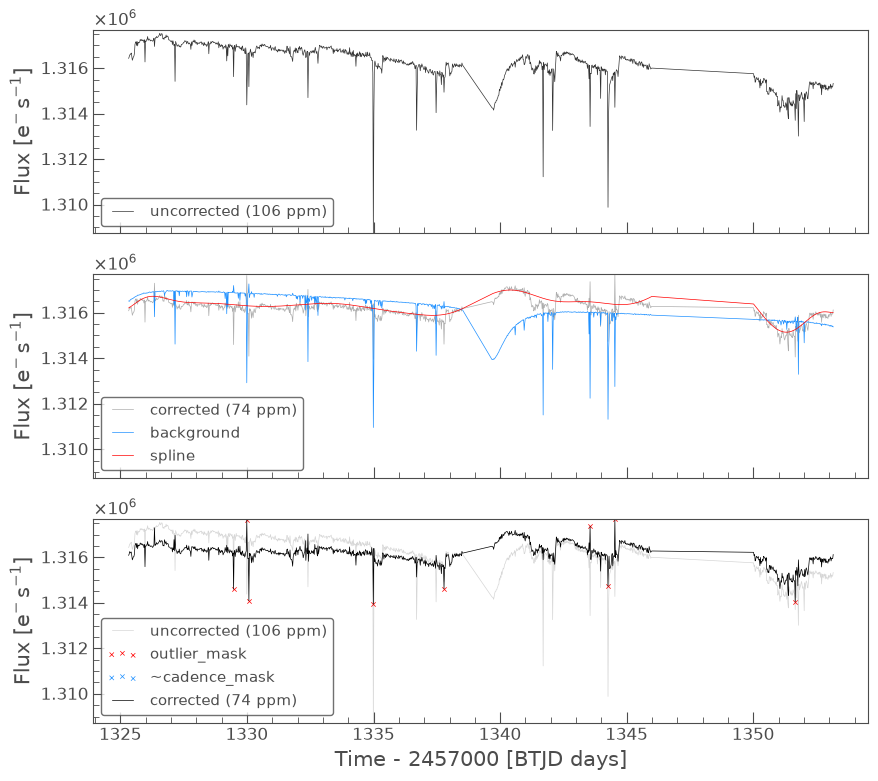

In [52]:
from lightkurve.correctors import PLDCorrector
pld = PLDCorrector(ffi_data[mask_ffi], aperture_mask=target_mask)
pld.correct(pca_components=3)
pltAxis = pld.diagnose()

corrected_ffi = pld.correct(pca_components=3)

*Compare non-corrected to corrected:*

(0.9975, 1.0025)

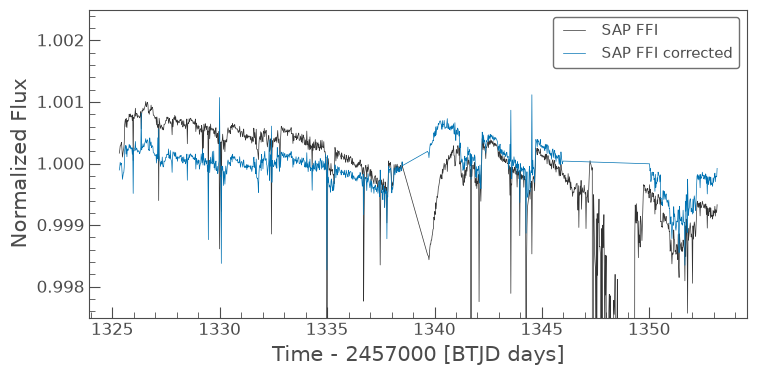

In [53]:
ax = ffi_lc.plot(normalize=True, label="SAP FFI");
corrected_ffi.remove_outliers().plot(ax=ax,normalize=True,label="SAP FFI corrected")
plt.ylim(0.9975,1.0025)

*Flatten:*

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

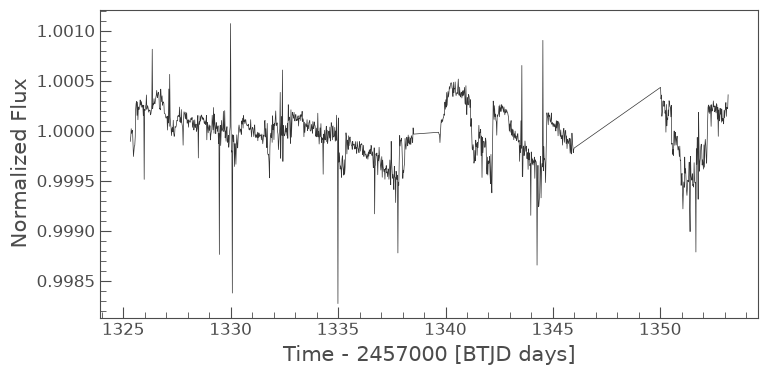

In [54]:
ffi_flat_lc = corrected_ffi.flatten(window_length=1001)
ffi_flat_lc.plot()

*Fold:*

(0.999, 1.001)

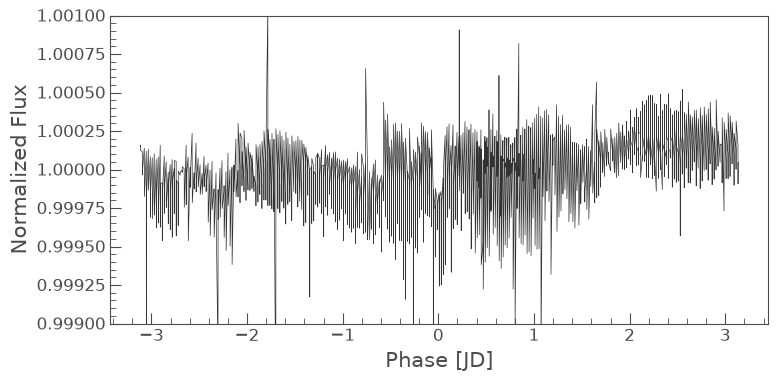

In [55]:
folded_ffi = ffi_flat_lc.fold(period=6.27, epoch_time=1325.504)
folded_ffi.plot()
plt.ylim(0.999,1.001)

*Compare to original, non-FFI, lightcurve:*

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

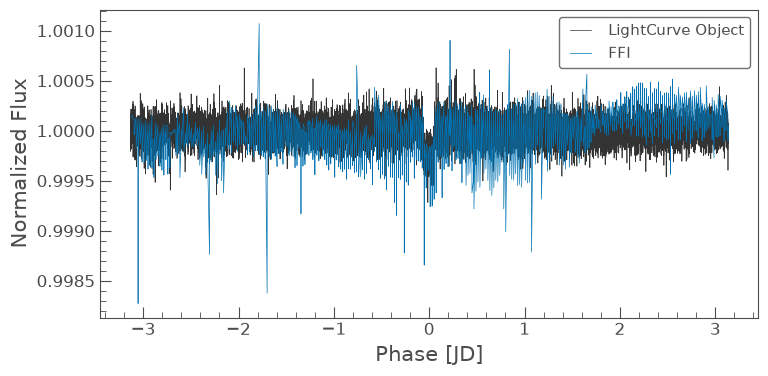

In [56]:
ax = folded_lc.plot(label="LightCurve Object")
folded_ffi.plot(ax=ax, label="FFI")


***THE END!! :)***